# First tests and models

In [ ]:
#Librairies import

import os
import pandas as pd
from merge_and_agregation import *
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import numpy as np
import matplotlib.pyplot as plt
from visualisation import plot_hist_top_k
import visualisation

import importlib

#Setting the environnement
os.chdir("/home/onyxia/work/bdc-alptis-g2/bdc-alptis-g2") 

In [226]:
#Loading of files
df_portefeuille= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_reclamations= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_interactions=pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_impayes= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")
df_consommations= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")

/tmp/ipykernel_83263/1497957394.py:2: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")


## Overview of target variable

In [ ]:
print(f"Percentage of resiliation during 2024: {(df["target_resiliation_6mois"]==1).sum()/df.shape[0]*100}")
print((df["target_resiliation_6mois"]==1).sum())

10.899408641081342
14450


14450 clients d'Alptis ont résilié entre 1er décembre 2023 
et le 31 mai 2024, soit 10,89 % des clients de l'année.

## Analyse de la target en lien avec les variables de réclamations

In [232]:
[column for column in df.columns if column.startswith("recla")]

['recla_nombre',
 'recla_motif_Couverture et fonctionnement de la garantie',
 'recla_motif_Délai de traitement',
 'recla_motif_Montant des remboursements / Indemnités',
 'recla_motif_Frais',
 'recla_motif_Demandes de compléments / pièces',
 'recla_motif_Autre',
 'recla_canal_entrant_principale',
 'recla_canal_entrant_secondaire',
 'recla_sensible_resiliation',
 'recla_sensible_tiers',
 'recla_sensible_courtier',
 'recla_sensible_autre',
 'recla_initiateur_client',
 'recla_non_cloturee',
 'recla_date_reception',
 'recla_delais_court',
 'recla_delais_moyen',
 'recla_delais_long']

In [233]:
df_reclamations.shape #11045 clients ayant faits des réclamations

(11045, 12)

Avec réclamation : 19.15325307723522 %
Sans réclamation : 10.411956895105567 %


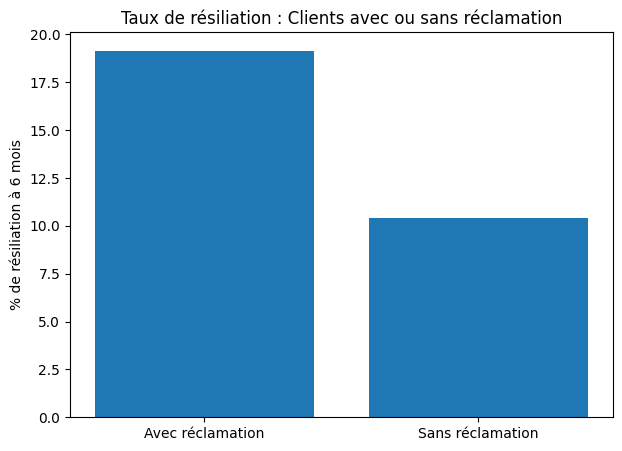

In [234]:
import matplotlib.pyplot as plt

# % résiliation chez les clients avec réclamation
pct_resiliation_recla = (
    df[df["recla_nombre"] > 0]["target_resiliation_6mois"].mean() * 100
)

# % résiliation chez les clients sans réclamation
pct_resiliation_sans_recla = (
    df[df["recla_nombre"] == 0]["target_resiliation_6mois"].mean() * 100
)

print("Avec réclamation :", pct_resiliation_recla, "%")
print("Sans réclamation :", pct_resiliation_sans_recla, "%")

# ---------- Plot ----------
labels = ["Avec réclamation", "Sans réclamation"]
values = [pct_resiliation_recla, pct_resiliation_sans_recla]

plt.figure(figsize=(7,5))
plt.bar(labels, values)
plt.ylabel("% de résiliation à 6 mois")
plt.title("Taux de résiliation : Clients avec ou sans réclamation")
plt.show()


Avec menace de résiliation : 27.500000000000004 %
Sans menace de résiliation : 10.89439850304823 %


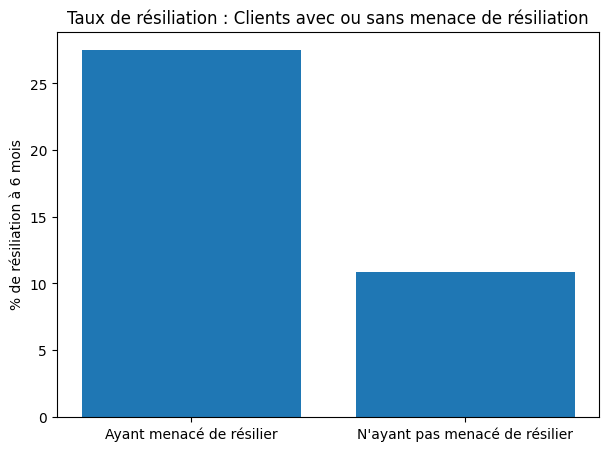

In [235]:
#Analyse menace résiliation vs résiliation réelle 

# % résiliation chez les clients ayant faits au moins une menace de résiliation
pct_resiliation_recla = (
    df[df["recla_sensible_resiliation"] > 0]["target_resiliation_6mois"].mean() * 100
)

# % résiliation chez les clients sans menace de résiliation
pct_resiliation_sans_recla = (
    df[df["recla_sensible_resiliation"] == 0]["target_resiliation_6mois"].mean() * 100
)

print("Avec menace de résiliation :", pct_resiliation_recla, "%")
print("Sans menace de résiliation :", pct_resiliation_sans_recla, "%")

# ---------- Plot ----------
labels = ["Ayant menacé de résilier", "N'ayant pas menacé de résilier"]
values = [pct_resiliation_recla, pct_resiliation_sans_recla]

plt.figure(figsize=(7,5))
plt.bar(labels, values)
plt.ylabel("% de résiliation à 6 mois")
plt.title("Taux de résiliation : Clients avec ou sans menace de résiliation")
plt.show()


<Axes: >

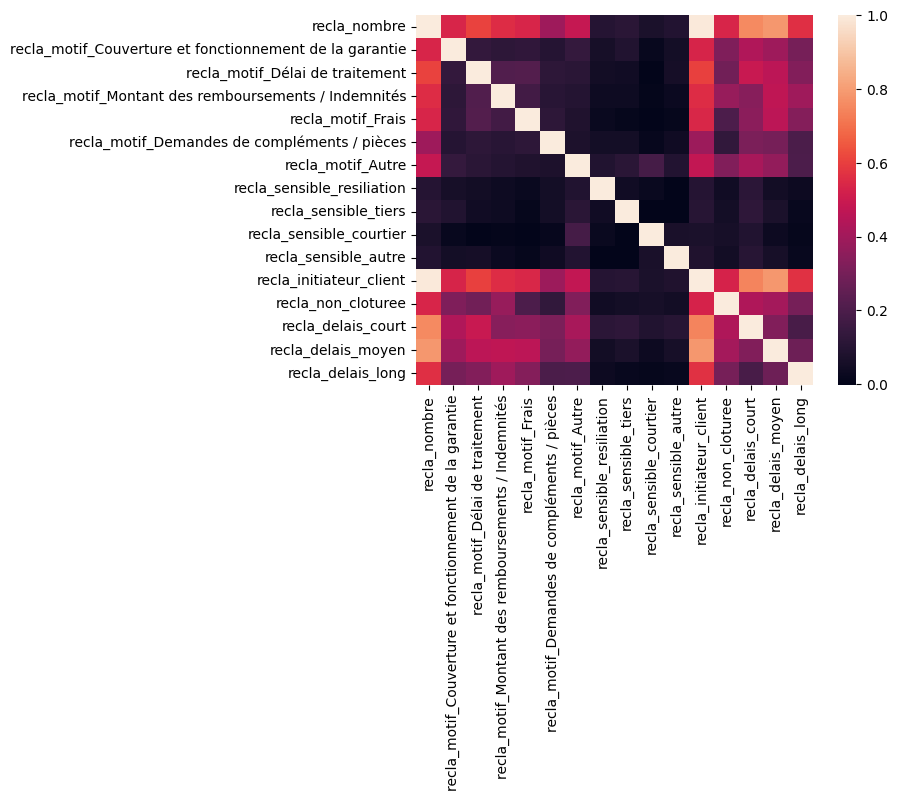

In [236]:
#Matrice de corrélation sur le fichier des réclamations
corr=df[[column for column in df.columns if column.startswith("recla") and column not in ["recla_canal_entrant_principale","recla_canal_entrant_secondaire","recla_date_reception"]]].dropna().corr()
sns.heatmap(corr)

Data Preparation

In [237]:
#Data Preparation 

#Creation of a dummy variable on secondary canal
df["recla_canal_secondaire"]=df["recla_canal_entrant_secondaire"].notna().astype(int)

#Definition of explanatory and explicative variables
X= df[["recla_sensible_resiliation","recla_nombre", "recla_delais_long", "recla_canal_secondaire"]]
y= df["target_resiliation_6mois"]

#Commentary: no need to standardize the variables since its only binary variables or compting variables between 0-10

#Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Logistic Regression

Accuracy: 0.8918766028058531
F1 score: 0.002782608695652174
Recall score: 0.0013951866062085804
Precision score: 0.0013951866062085804


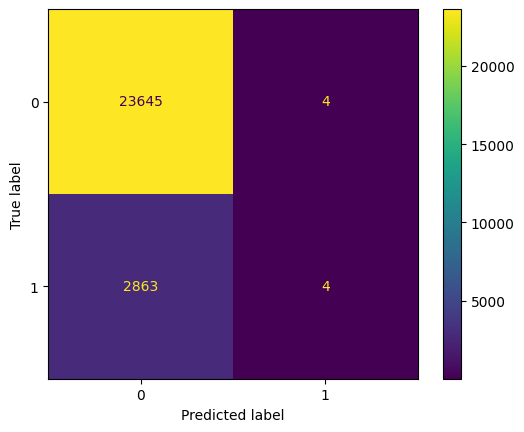

In [238]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score, precision_score
lr =LogisticRegression()

lr.fit(X_train, Y_train)

#Accuracy
print(f"Accuracy: {lr.score(X_test, Y_test)}")

#Confusion Matrix
cm= confusion_matrix(Y_test, lr.predict(X_test))
ConfusionMatrixDisplay(cm).plot()

#F1, Recall, Precision
print(f"F1 score: {f1_score(Y_test, lr.predict(X_test))}")
print(f"Recall score: {recall_score(Y_test, lr.predict(X_test))}")
print(f"Precision score: {recall_score(Y_test, lr.predict(X_test))}")

In [239]:
print(f"Pourcentage de clients ayant résiliés dans le dataset train: {(Y_train.sum()/len(Y_train)*100).round(0)}%")

Pourcentage de clients ayant résiliés dans le dataset train: 11.0%


Accuracy: 0.8568034394327952
F1 score: 0.1285288042230893
Recall score: 0.09766306243460063
Precision score: 0.18791946308724833


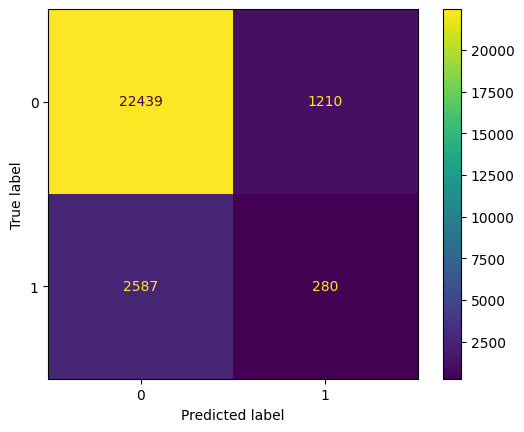

In [ ]:
#Logistique regression en équilibrant la répartition du label avec "class_weight = balanced"
#permet de donner un poids plus fort aux erreur de misclassification sur la classe 1

lr =LogisticRegression(class_weight='balanced') #Equilibrage du label

lr.fit(X_train, Y_train)
print(f"Accuracy: {lr.score(X_test, Y_test)}")

#Confusion Matrix
cm= confusion_matrix(Y_test, lr.predict(X_test))
ConfusionMatrixDisplay(cm).plot()

#Recall, Precision, F1
print(f"F1 score: {f1_score(Y_test, lr.predict(X_test))}")
print(f"Recall score: {recall_score(Y_test, lr.predict(X_test))}") 
print(f"Precision score: {precision_score(Y_test, lr.predict(X_test))}")

**Conclusion de la régression logistique**

Un bon score d'accuracy, mais en réalité une mauvaise classification si l'on regarde le F1 et la matrice de confusion: seuls 4 clients ayant résiliés sont bien classifiés par le modèle ! 
En fait, les données sont déséquilibrées entre la classe 0 (pas de résiliation) et 1 (résiliation): il y a très peu de clients qui ont résilié (11%), donc le modèle prédit toujours 0 ce qui donne une bonne accuracy, mais mauvais en pratique. 

Amélioration mais problème persiste lorsqu'on donne un poids plus fort aux erreurs sur la classe minoritaire 0 avec "class_weight= balanced" (même si 304 clients ayant résilié correctement classifiés au lieu de 1)

**Commentaire sur la mesure de la classification**
- L'accuracy est une mauvaise mesure du modèle dans notre contexte de données déséquilibrées. On préfère mesurer le Recall/Precision/F1. 
- Recall= TP/(TP+FN) -> Nbre de fois où prédit 1 correctement, parmi toutes les données associées à 1
- Precision = TP/(TP+FP) -> Nbre de fois où prédit 1 correctement, parmi toutes les fois où on a prédit 1
- F1 = Recall*Precision/(Precision+Recall) -> Mesure équilibrée entre le Recall et la Précision

Le Recall plus important dans notre problème car plus important: ne pas  misclassifier un client ayant résilié.

Testons des modèles d'ensemble, plus adaptés aux données déséquilibrées: RandomForest et XGBoost

Random Forest

In [241]:
#RandomForest
from sklearn.ensemble import RandomForestClassifier

# Train and Test
rf= RandomForestClassifier(class_weight= "balanced")
rf.fit(X_train, Y_train)

#Scores
print(f"Recall score: {recall_score(Y_test, rf.predict(X_test))}")
print(f"Precision score: {precision_score(Y_test, rf.predict(X_test))}")

Recall score: 0.09591907917683991
Precision score: 0.18848526387936942


XGBoost

In [242]:

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

#Label encoding to conduct XGBoost
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.fit_transform(Y_test)


xgboost= XGBClassifier(scale_pos_weight = (Y_train.sum() / (len(Y_train)-Y_train.sum()))) #balance les données pour donner + de poids à 1
xgboost.fit(X_train, Y_train_encoded)

#Precision, Recall
print(f"Recall score: {recall_score(Y_test, xgboost.predict(X_test))}") #pire que randomforest et logistic regression
print(f"Precision score: {precision_score(Y_test, xgboost.predict(X_test))}")

Recall score: 0.0
Precision score: 0.0


/opt/python/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Pas d'amélioration, voire une détérioration du Recall avec RandomForest et XGBoost.

 Tentons de rééquilibrer totalement les données avec **SMOTE** (technique qui permet de générer des données synthétiques portant le label 0) pour atteindre un équilibre 50% entre résiliation et non résiliation dans le dataset test et retestons tous les modèles;

In [243]:
#Equilibre du dataset train avec SMOTE (resampling)
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_res, Y_res = sm.fit_resample(X_train, Y_train)

#Entrainement et test des modèles avec mesure de score 

#Logistic Regression
lr =LogisticRegression()
lr.fit(X_res, Y_res)
print(f"Recall score Logistic Regression: {recall_score(Y_test, lr.predict(X_test))}")
print(f"Precision score Logistic Regression: {precision_score(Y_test, lr.predict(X_test))}")

#RandomForest
rf= RandomForestClassifier()
rf.fit(X_res, Y_res)
print(f"Recall score Random Forest: {recall_score(Y_test, rf.predict(X_test))}")
print(f"Precision score Random Forest:  {precision_score(Y_test, rf.predict(X_test))}")
from sklearn.ensemble import RandomForestClassifier


#XGBoost
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.fit_transform(Y_test)
xgboost= XGBClassifier() 
xgboost.fit(X_train, Y_train_encoded)
print(f"Recall score of XGBoost: {recall_score(Y_test, xgboost.predict(X_test))}") #pire que randomforest et logistic regression
print(f"Precision score of XGBoost: {precision_score(Y_test, xgboost.predict(X_test))}")

Recall score Logistic Regression: 0.09766306243460063
Precision score Logistic Regression: 0.18791946308724833
Recall score Random Forest: 0.09557028252528776
Precision score Random Forest:  0.18857536132140398
Recall score of XGBoost: 0.0010463899546564353
Precision score of XGBoost: 0.75


Le SMOTE améliore légèrement les scores du XGBoost mais globalement mauvais score pour tous les modèles. Le meilleur modèle en terme de Recall est toujours la Régression Logistique.

Analysons les signaux portés par les différentes variables explicatives pour voir si le problème du modèle ne vient pas de là.

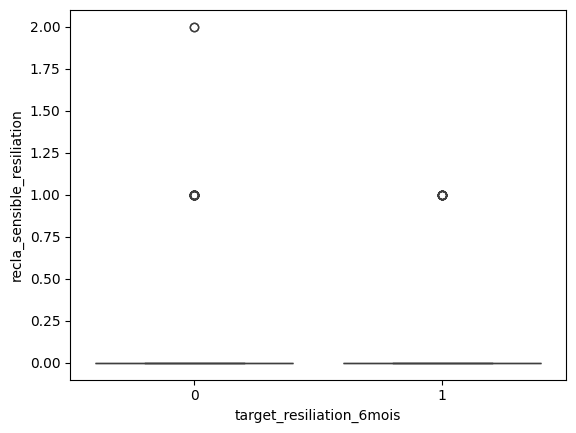

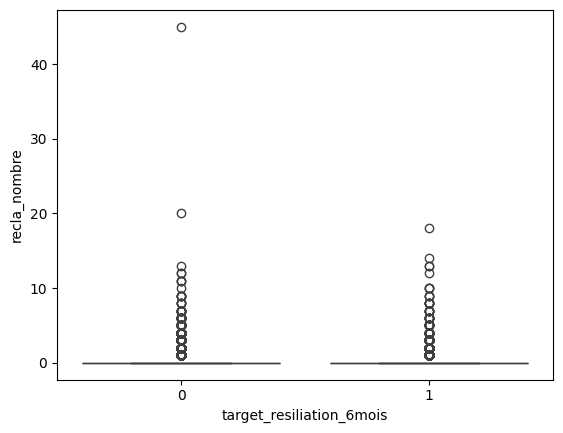

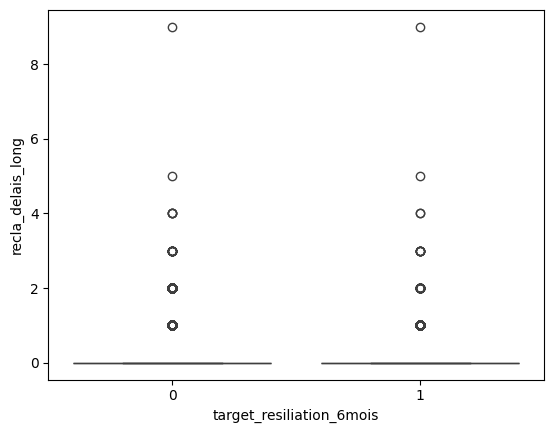

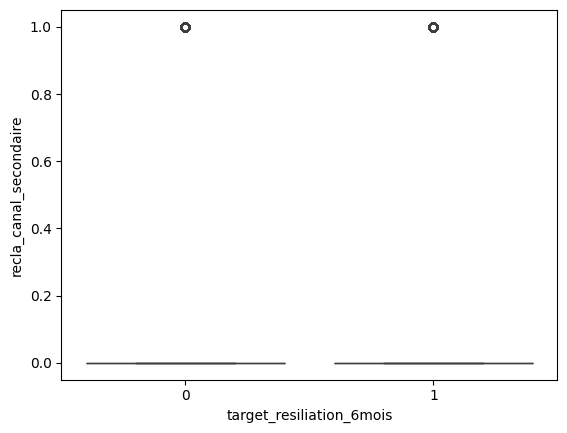

In [244]:
#Analyse des signaux portés par chaque variable explicative par boxplot (comparaison boxplot 1 et 0)

for col in X.columns:
    sns.boxplot(x=Y, y=X[col])
    plt.show()


Les variables explicatives ont des distributions presque identitiques pour y=1 et y=0. Ainsi, les variables explicatives sélectionnées ne semblent pas porter de signal assez fort pour différencier une résiliation d'une non résiliation, d'où les scores très faibles de tous les modèles testés.

 ### Détection de signaux sur les variables liées aux réclamations

<Axes: >

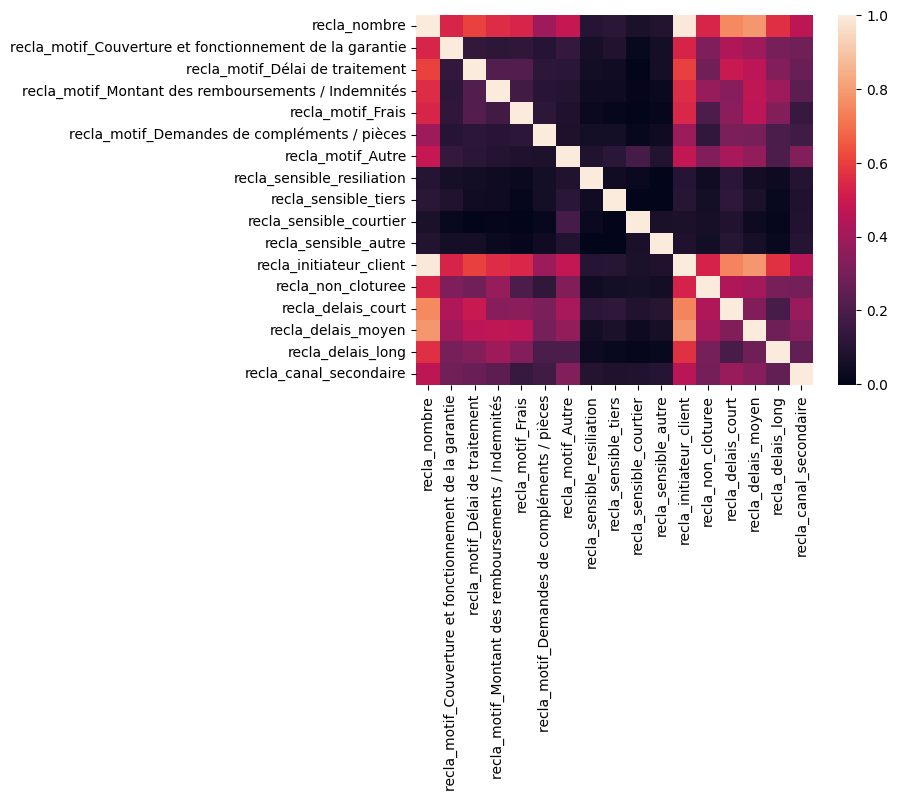

In [245]:
#Matrice de corrélation sur les variables des réclamations pour détecter les variables corrélées
corr=df[[column for column in df.columns if column.startswith("recla") and column not in ["recla_canal_entrant_principale","recla_canal_entrant_secondaire","recla_date_reception"]]].dropna().corr()
sns.heatmap(corr)

In [246]:

#Feature importance sur toutes les colonnes de reclamation non catégorielles
rf = RandomForestClassifier()
X= df[[c for c in df.columns if c.startswith("recla") if c not in ["recla_canal_entrant_principale","recla_canal_entrant_secondaire","recla_date_reception"] ]]
rf.fit(X, Y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

recla_initiateur_client                                    0.125285
recla_delais_court                                         0.098399
recla_delais_moyen                                         0.097427
recla_nombre                                               0.082653
recla_non_cloturee                                         0.079671
recla_delais_long                                          0.068849
recla_motif_Délai de traitement                            0.068310
recla_motif_Couverture et fonctionnement de la garantie    0.064703
recla_motif_Montant des remboursements / Indemnités        0.061946
recla_motif_Autre                                          0.055365
recla_motif_Frais                                          0.053234
recla_canal_secondaire                                     0.052787
recla_motif_Demandes de compléments / pièces               0.050244
recla_sensible_tiers                                       0.015160
recla_sensible_courtier                         

La feature importance reste assez faible pour toutes les variables, et domine sur recla_initiateur_client et recla_nombre. Toutefois, la feature importance n'est pas robuste aux corrélations entre variable: une feature détectée comme pas importante dans une liste de variables, peut se révélée avoir de l'importance dans une autre sous-liste de cette même liste de variable. 

Faisons un test SHAP, plus robuste aux corrélations entre variables, et cela toujours sur des variables explicatives liées aux réclamations. Pour cela, nous utilisons le modèle de Régression Logistique qui a eu le meilleur score de Recall précédemment (0.204)

              precision    recall  f1-score   support

           0       0.95      0.90      0.92     37544
           1       0.10      0.19      0.13      2229

    accuracy                           0.86     39773
   macro avg       0.52      0.54      0.53     39773
weighted avg       0.90      0.86      0.88     39773



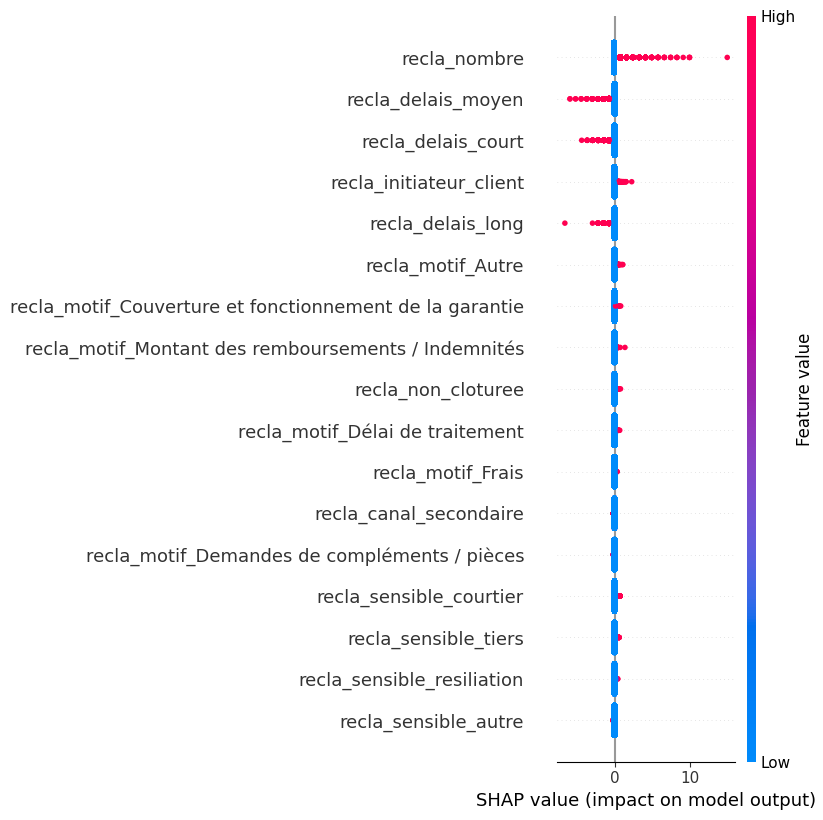

In [247]:
from sklearn.metrics import classification_report
import shap

# Train and Test sur Logistic Regression
#Remarque: on ne va pas resampler avec SMOT (car SMOT n'augmentait pas le recall de logistic régression)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1) 
lr=LogisticRegression(class_weight="balanced")
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Classification Report (nuancer les résultat du SHAP car recall seulement de 0.19 sur la classe 1)
print(classification_report(y_pred, y_test))

#Shap test avec LinearExplainer
explainer = shap.LinearExplainer(lr, X_train) #chargement d'un shap adapté au modèle
shap_values = explainer.shap_values(X_test) #calcul linear explainer sur test
shap.summary_plot(shap_values, X_test) #visualisation

**Premières conclusion intéressantes**

D'après le linéaire SHAP, trois variables envoie des signaux un peu plus forts:
- recla_nombre envoie un signal positif sur la target: un client avec beaucoup de réclamation envoie un signal de risque de résiliation 
- recla_delais_moyen et recla_delais_court envoient des signaux négatifs sur la target: un client ayant un nombre élevé de réclamations traitées dans des délais inférieurs à 15 jours indiquent un risque plus faible de résiliation. 

Résultat à nuancer: 
- Le signal principal à retenir est celui sur recla_nombre car les variables sur les délais courts et moyens sont corrélées à recla_nombre, étant donné que la majorité des réclamations sont faites dans des délais courts voire moyens (cf matrice corrélation également)
- SHAP value à nuancer étant donné que calculé sur modèle avec un recall = 0.19 (=304 lignes bien prédites)

On retiendra l'unique variable **recla_nombre** sur le fichier de réclamation pour l'instant.

## Analyse de la target en lien avec les variables liées au courtier

### Analyse des corrélations des variables liées aux courtiers

<Axes: >

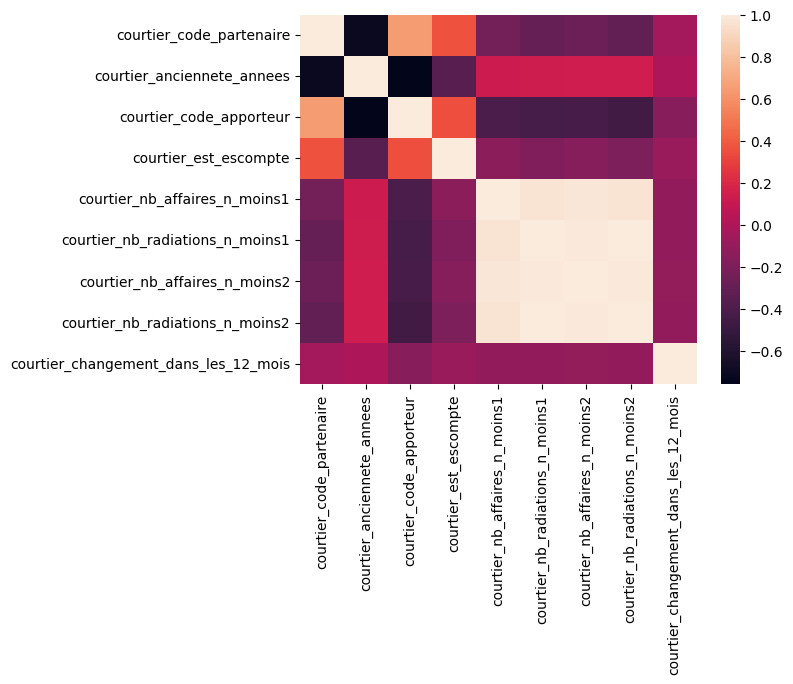

In [ ]:
#Creation boolean sur courtier_code_changement_dans_les_12_mois
df["courtier_changement_dans_les_12_mois"]=df["courtier_code_avant_changement_12_mois"].notna().astype(int)

#Sélection des variables courtier non catégorielles
X= df[[c for c in df.columns if c.startswith("courtier") if c not in ["courtier_code_avant_changement_12_mois","courtier_segmentation_interne","courtier_reseau_courtage","courtier_type_commission"] ]]

corr=X.dropna().corr()
sns.heatmap(corr)

### Visualisation rapide des courtiers (code partenaire) avec le plus de résiliations

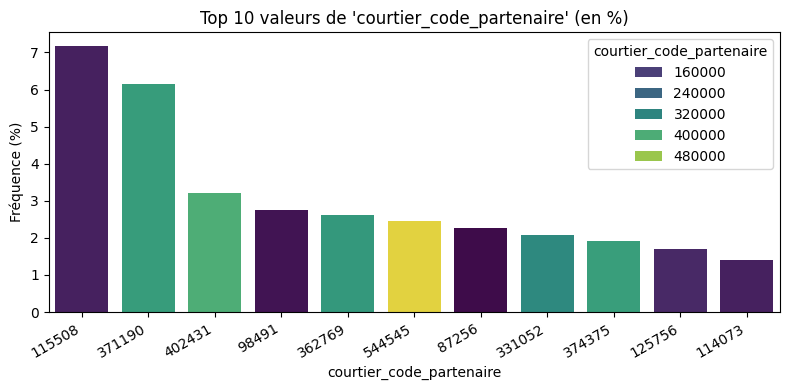

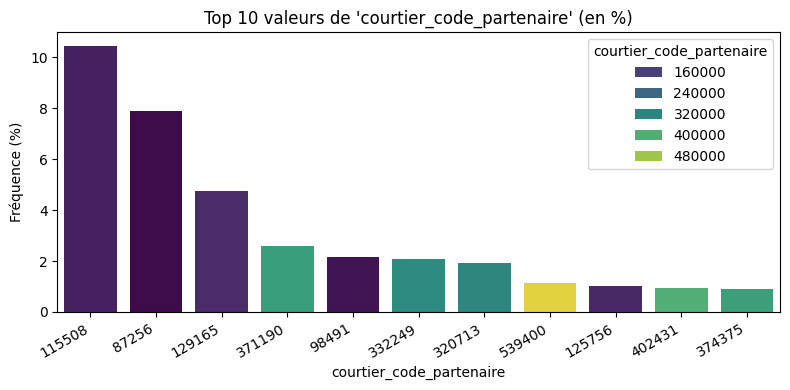

In [251]:
#Courtiers ayant le nombres de clients ayant résilié le plus élévé
plot_hist_top_k(df[df["target_resiliation_6mois"]==1], ["courtier_code_partenaire"], k=10)

#Courtiers les plus présents dans le portefeuille d'Alptis (en terme de nombre de clients associés)
plot_hist_top_k(df, ["courtier_code_partenaire"], 10)

/tmp/ipykernel_83263/487858252.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


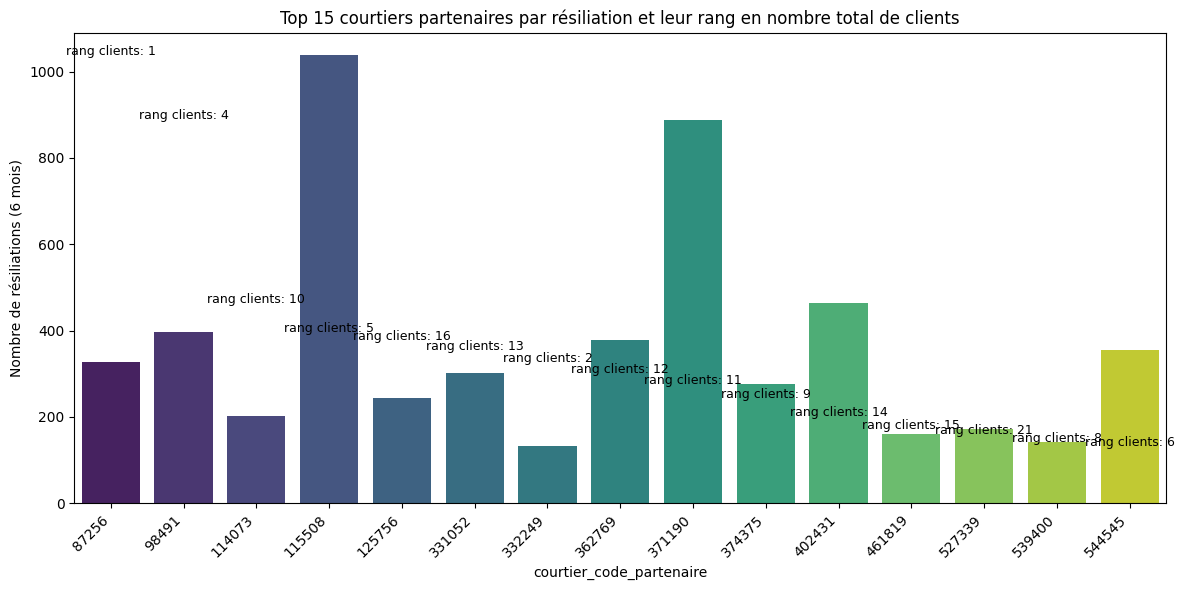

In [257]:

# Nombre de résiliations par code partenaire
resil_counts = df.groupby("courtier_code_partenaire")["target_resiliation_6mois"].sum()

# Top 20 codes partenaires par résiliation
top15_resil = resil_counts.sort_values(ascending=False).head(15)
top15_codes = top15_resil.index.tolist()

# 3Nombre total de clients par code partenaire
total_clients = df.groupby("courtier_code_partenaire")["target_resiliation_6mois"].count()

#  Rang des codes top20 selon nombre total de clients
total_clients_rank = total_clients.rank(method="min", ascending=False)
top15_rank = total_clients_rank[top15_codes]

#  Préparer DataFrame pour plot
plot_df = pd.DataFrame({
    "courtier_code_partenaire": top15_codes,
    "nb_resil": top15_resil.values,
    "total_clients": total_clients[top15_codes].values,
    "rang_total_clients": top15_rank.values
})

plot_df = plot_df.sort_values("nb_resil", ascending=False)

# 6️ Visualisation
plt.figure(figsize=(12,6))
sns.barplot(
    data=plot_df,
    x="courtier_code_partenaire",
    y="nb_resil",
    palette="viridis", 
    #order= plot_df["nb_resil"]
)

# Ajouter le rang total clients au-dessus des barres
for i, row in plot_df.iterrows():
    plt.text(
        i, row.nb_resil + 0.5,
        f"rang clients: {int(row.rang_total_clients)}",
        ha="center", fontsize=9
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Nombre de résiliations (6 mois)")
plt.title("Top 15 courtiers partenaires par résiliation et leur rang en nombre total de clients")
plt.tight_layout()
plt.show()

In [253]:
df["courtier_code_partenaire"].nunique()

4862

On remarque que les courtiers avec le plus de résiliation en nombre sur l'année 2023, sont tout simplement les courtiers avec le plus de clients au sein d'Alptis. Ainsi, il est plus pertinent d'analyser les résiliations de chaque courtier en terme de **pourcentage résiliation interne à chaque courtier**

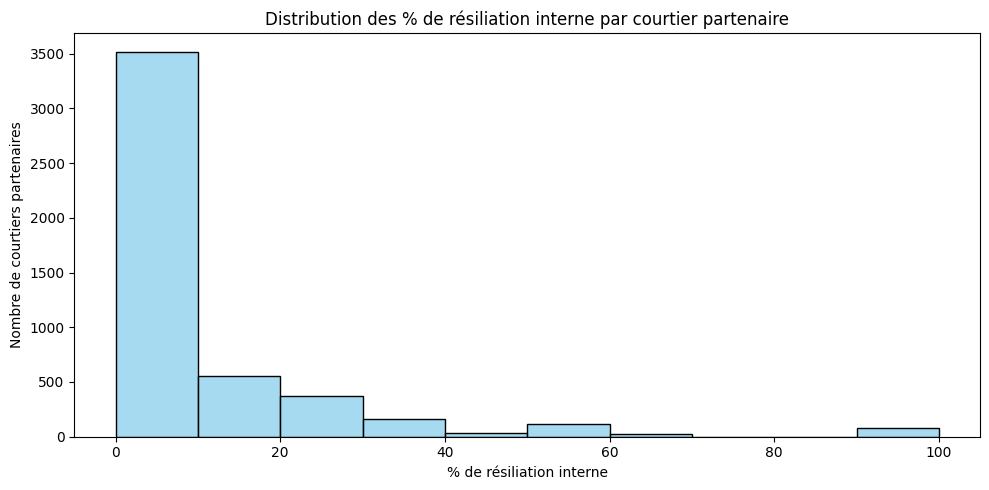

In [254]:
#Création d'un dictionnaire qui associé à un code courtier partenaire son % de résiliation

#Dictionnaire associant à un code partenaire courtier son nombre de client en 2023
dict_client_courtier= df["courtier_code_partenaire"].value_counts().to_dict()

#Dictionnaire associant à un code partenaire courtier son nombre de résiliation en 2023
dict_resiliation_courtier=df.groupby("courtier_code_partenaire").agg({"target_resiliation_6mois": "sum"}).to_dict()["target_resiliation_6mois"]

#Calcul du % de résiliation interne à chaque courtier
dict_pourc_resiliation_courtier= dict()
for courtier in dict_client_courtier.keys():
    dict_pourc_resiliation_courtier[courtier]= dict_resiliation_courtier[courtier]/dict_client_courtier[courtier]*100

df_resiliation = pd.DataFrame(list(dict_pourc_resiliation_courtier.items()), columns=["courtier_code_partenaire", "resiliation_pct"])

# Visualisation
plt.figure(figsize=(10,5))
sns.histplot(df_resiliation["resiliation_pct"], bins=10, kde=False, color="skyblue")
plt.xlabel("% de résiliation interne")
plt.ylabel("Nombre de courtiers partenaires")
plt.title("Distribution des % de résiliation interne par courtier partenaire")
plt.tight_layout()
plt.show()

In [258]:

print(f"Nombre de courtiers partenaires avec 100% de résiliation interne: {list(dict_pourc_resiliation_courtier.values()).count(100)}")
print(f"Nombre de courtiers partenaires avec plus de 50 % de résiliation interne: {sum(1 for v in dict_pourc_resiliation_courtier.values() if v > 50)}")
print(f"Nombre de courtiers partenaires avec moins de 10% de résiliation interne: {sum(1 for v in dict_pourc_resiliation_courtier.values() if v < 10)}")
print(f"Nombre de courtiers partenaires totaux chez Alptis: {df["courtier_code_partenaire"].nunique()}")

Nombre de courtiers partenaires avec 100% de résiliation interne: 80
Nombre de courtiers partenaires avec plus de 50 % de résiliation interne: 113
Nombre de courtiers partenaires avec moins de 10% de résiliation interne: 3514
Nombre de courtiers partenaires totaux chez Alptis: 4862


In [ ]:
#Faire plot répartition en nombre de clients sur chacune des catégorie (80-100%, 50-80, ...): 
#ex: parmi les clients avec entre 80-100% de résil combien en part ont moins de 100 clients, ...
#Puis ensuite conclure

### Modèle de prédictions simples pour prédire le taux de résiliation interne chez un courtier partenaire

Tentons de **prédire pour un certain courtier partenaire, le taux de résiliation interne.**

Pour pouvoir appliquer des modèles sur les variables liées aux courtiers, nous devons d'abord agrégé le DataFrame selon le courtier_code_partenaire. 

In [ ]:
#Création d'un dataframe agrégé par type de courtier
#Finir fonction et créer une fonction qu'on exportera dans aggregation_and_merge pour pouvoir réutiliser le df agrégé
#on crée des bins pour voir si classification fonctionne: au moins assez bonne pour diff entre classe extreme
# on passe à regression directe.


# Merge des données
df_courtier = df_resiliation.merge(df, on=["courtier_code_partenaire"])

# Définition des bins et valeurs numériques pour la résiliation
bins = [0, 25, 50, 80, 100]   # bornes : 0-25%, 25-50%, 50-80%, 80-100%
labels_num = [1, 2, 3, 4]     # 1=faible, 2=moyenne, 3=forte, 4=très forte

# Créer colonne numérique resiliation_cat (1-4)
df_courtier["resiliation_cat"] = pd.cut(
    df_courtier["resiliation_pct"],
    bins=bins,
    labels=labels_num,
    right=True,
    include_lowest=True
).astype(int)

# Vérification : courtiers avec résiliation très forte (4)
clients_très_forts = df_courtier[df_courtier["resiliation_cat"] == 4]
print("Courtiers avec résiliation très forte et nombre de clients associés :")
print(clients_très_forts.groupby("courtier_code_partenaire")["client_code"].count())

# Nombre de clients par courtier
df_courtier["nbre_client"] = df_courtier.groupby("courtier_code_partenaire")["client_code"].transform("count")

# Agrégation par courtier
df_agg = df_courtier.groupby("courtier_code_partenaire").agg({
    "resiliation_cat": "first",                      # chaque courtier a une seule catégorie
    "nbre_client": "first",                          # nombre total de clients
    "courtier_anciennete_annees": "first",          # ancienneté
    "courtier_segmentation_interne": "first"        # segmentation interne
}).reset_index()

# df_agg est prêt pour clusterisation

# Liste des colonnes à sommer
colonnes_sum = [
    "courtier_est_escompte",
    "courtier_nb_affaires_n_moins1",
    "courtier_nb_radiations_n_moins1",
    "courtier_nb_affaires_n_moins2",
    "courtier_nb_radiations_n_moins2"
]
colonnes_unique= [ "courtier_reseau_courtage",
                   "courtier_segmentation_interne",
                    "courtier_type_commission",
                    "courtier_anciennete_annees"
                    ]

# Agréger par courtier : prendre la première valeur pour chaque colonne
df_agg_suppl = df_courtier.groupby("courtier_code_partenaire")[colonnes_sum].agg("first").reset_index()

# Merge avec df_agg existant
df_agg = df_agg.merge(df_agg_sum, on="courtier_code_partenaire", how="left").agg("sum")

# Vérification
print(df_agg.head())


Courtiers avec résiliation très forte et nombre de clients associés :
courtier_code_partenaire
73851     1
86024     1
92723     1
93388     1
97686     1
         ..
544188    1
546582    1
548871    1
550348    1
550467    1
Name: client_code, Length: 80, dtype: int64


KeyError: "Columns not found: 'courtier_nb_radiations_n_moins2courtier_code_'"

## Suite des test